In [ ]:
import os
os.chdir("..")


In [1]:
import cv2
from PIL import Image
import glob
import numpy as np
from matplotlib import pyplot as plt
from patchify import patchify, unpatchify
import scipy
import scipy.io as sio 
from scipy.io import readsav
import os, sys
import imutils
import pandas as pd
import math
from array import array

In [5]:
import h5py
import glob
import numpy as np
import cv2
import os
from datetime import datetime

# Initialize list to store filtered masks
mask_filtered = []

# Path to directory containing .h5 files
h5_files = sorted(glob.glob("/home/dibya/ML_project/activity_prediction/*.h5"))

# Parameters
area_threshold = 600  # Set your desired threshold here #80,600
kernel_size = (2, 2)  # for morphological closing

# Loop through each file and read the data
for h5_file in h5_files:
    with h5py.File(h5_file, "r") as f:
        # Read and preprocess mask
        mask = f["mask"][:].clip(max=1)
        #mask = cv2.flip(mask, 1)
        
        # Perform morphological closing
        kernel = np.ones(kernel_size, np.uint8)
        closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
        
        # Apply connected component analysis
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            closing.astype(np.uint8), connectivity=8)
        
        # Create filtered mask
        filtered_mask = np.zeros_like(closing, dtype=np.uint8)
        for i in range(1, num_labels):  # Skip background (label 0)
            if stats[i, cv2.CC_STAT_AREA] >= area_threshold:
                filtered_mask[labels == i] = 1
        
        # Append the filtered mask to our list
        mask_filtered.append(filtered_mask)
        
        # Optional: Save or display the filtered mask
        # cv2.imwrite(f"filtered_mask_{k}.png", filtered_mask * 255)
        # plt.imshow(filtered_mask, cmap='gray')
        # plt.show()

# Now mask_filtered contains all processed masks
print(f"Processed {len(mask_filtered)} masks")

Processed 3 masks


In [6]:
filtered_img = np.array(mask_filtered)

/tmp/ipykernel_879059/4184105011.py:53: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax1.contour(filtered_img[2],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
/tmp/ipykernel_879059/4184105011.py:63: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax4.contour(filtered_img[2],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)
/tmp/ipykernel_879059/4184105011.py:73: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax2.contour(filtered_img[1],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
/tmp/ipykernel_879059/4184105011.py:83: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax5.contour(filtered_img[1],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2, rasterized=True)
/tmp/ipykernel_879059/4184105011.py:93: UserWarning: Th

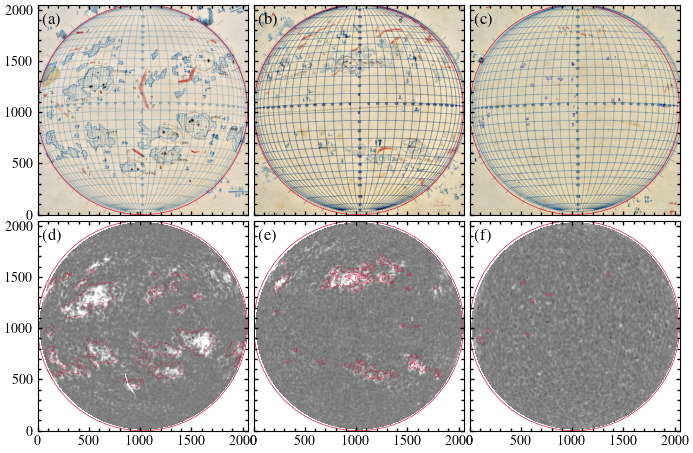

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import imutils
from PIL import Image
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

from matplotlib.patches import Circle

# read 'sav' files
sav_data_max = readsav("/home/dibya/ML_project/plage_overlap_19580109_0824.sav") 
sav_data_middle = readsav("/home/dibya/ML_project/plage_overlap_19560101_0746.sav") 
sav_data_min = readsav("/home/dibya/ML_project/plage_overlap_19540101_1352.sav")

fig=plt.figure(figsize = (6,6))

ax1 = fig.add_axes([0.01,0.37,0.35, 0.35])
ax2 = fig.add_axes([0.37,0.37,0.35, 0.35])
ax3 = fig.add_axes([0.73,0.37,0.35, 0.35])
ax4 = fig.add_axes([0.01,0.01,0.35, 0.35])
ax5 = fig.add_axes([0.37,0.01,0.35, 0.35])
ax6 = fig.add_axes([0.73,0.01,0.35, 0.35])

reconstruct_maxmima = cv2.imread('/home/dibya/ML_project/maxima_activity_img/sch_19580109_0812_kkkk_sharpen.tif', cv2.IMREAD_COLOR) 
reconstruct_maxmima = cv2.cvtColor(reconstruct_maxmima, cv2.COLOR_BGR2RGB)
reconstruct_maxmima = cv2.flip(reconstruct_maxmima, 0)
reconstruct_maxmima = imutils.rotate(reconstruct_maxmima,angle=0.0)
reconstruct_maxmima = reconstruct_maxmima[3024-2424:3024+2424,3048-2424:3048+2424]
reconstruct_maxmima = Image.fromarray(reconstruct_maxmima)
reconstruct_maxmima = reconstruct_maxmima.resize((2048,2048))

reconstruct_middle = cv2.imread('/home/dibya/ML_project/middle_activity_img/sch_19560101_0750_kkkk_sharpen.tif', cv2.IMREAD_COLOR) 
reconstruct_middle = cv2.cvtColor(reconstruct_middle, cv2.COLOR_BGR2RGB)
reconstruct_middle = cv2.flip(reconstruct_middle, 0)
reconstruct_middle = imutils.rotate(reconstruct_middle,angle=-1.0)
reconstruct_middle = reconstruct_middle[2976-2400:2976+2400,3072-2400:3072+2400]
reconstruct_middle = Image.fromarray(reconstruct_middle)
reconstruct_middle = reconstruct_middle.resize((2048,2048))

reconstruct_minimum = cv2.imread('/home/dibya/ML_project/minimum_activity_img/sch_19540101_0803_kkkk_sharpen.tif', cv2.IMREAD_COLOR) 
reconstruct_minimum = cv2.cvtColor(reconstruct_minimum, cv2.COLOR_BGR2RGB)
reconstruct_minimum = cv2.flip(reconstruct_minimum, 0)
reconstruct_minimum = imutils.rotate(reconstruct_minimum,angle=-1.0)
reconstruct_minimum = reconstruct_minimum[3072-2400:3072+2400,2952-2400:2952+2400]
reconstruct_minimum = Image.fromarray(reconstruct_minimum)
reconstruct_minimum = reconstruct_minimum.resize((2048,2048))


# Display images
ax1.imshow(reconstruct_maxmima,origin='lower',rasterized=True)
ax1.contour(filtered_img[2],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
ax1.annotate('(a)', (45,1850), fontsize=12)
ax1.tick_params(axis='both', labelsize=10,labelbottom=False)
ax1.set_xticks([0,500,1000,1500,2000])
ax1.set_yticks([0,500,1000,1500,2000])
circle = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5,   rasterized=True)
ax1.add_patch(circle)
ax1.grid()

ax4.imshow(sav_data_max['resized_data'],cmap='gray',origin='lower',vmin=-0.5,vmax=0.5, rasterized=True)
ax4.contour(filtered_img[2],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)
ax4.annotate('(d)', (45,1850), fontsize=12)
ax4.tick_params(axis='both', labelsize=10)
ax4.set_xticks([0,500,1000,1500,2000])
ax4.set_yticks([0,500,1000,1500,2000])
circle1 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5, rasterized=True)
ax4.add_patch(circle1)
ax4.grid()

ax2.imshow(reconstruct_middle,origin='lower',rasterized=True)
ax2.contour(filtered_img[1],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
ax2.annotate('(b)', (45,1850), fontsize=12)
ax2.tick_params(axis='both', labelsize=10,labelleft= False,labelbottom=False)
ax2.set_xticks([500,1000,1500,2000])
ax2.set_yticks([0,500,1000,1500,2000])
circle1 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5, rasterized=True)
ax2.add_patch(circle1)
ax2.grid()

ax5.imshow(sav_data_middle['resized_data'],cmap='gray',origin='lower',vmin=-0.5,vmax=0.5, rasterized=True)
ax5.contour(filtered_img[1],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2, rasterized=True)
ax5.annotate('(e)', (45,1850), fontsize=12)
ax5.tick_params(axis='both', labelsize=10,labelleft=False)
ax5.set_xticks([0,500,1000,1500,2000])
ax5.set_yticks([0,500,1000,1500,2000])
circle2 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5, rasterized=True)
ax5.add_patch(circle2)
ax5.grid()

ax3.imshow(reconstruct_minimum,origin='lower',rasterized=True)
ax3.contour(filtered_img[0],alpha=0.07, colors='crimson', linestyles='-',origin='lower',linewidths=0.01, rasterized=True)
ax3.annotate('(c)', (45,1850), fontsize=12)
ax3.tick_params(axis='both', labelsize=10,labelleft= False,labelbottom=False)
ax3.set_xticks([500,1000,1500,2000])
ax3.set_yticks([0,500,1000,1500,2000])
circle3 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5, rasterized=True)
ax3.add_patch(circle3)
ax3.grid()

ax6.imshow(sav_data_min['resized_data'],cmap='gray',origin='lower',vmin=-0.5,vmax=0.5, rasterized=True)
ax6.contour(filtered_img[0],alpha=0.2, colors='crimson', linestyles='-',origin='lower',linewidths=0.2, rasterized=True)
ax6.annotate('(f)', (45,1850), fontsize=12)
ax6.tick_params(axis='both', labelsize=10,labelleft=False)
ax6.set_xticks([0,500,1000,1500,2000])
ax6.set_yticks([0,500,1000,1500,2000])
circle4 = Circle((1024,1024),1024, color='crimson', fill=False, linewidth=0.5,rasterized=True)
ax6.add_patch(circle4)
ax6.grid()

plt.tight_layout()
plt.savefig('activity_comp_img.pdf', bbox_inches='tight', pad_inches=0, dpi=200)

/tmp/ipykernel_879059/2492964322.py:75: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax.contour(contour_data, alpha=0.4, colors='crimson',
/tmp/ipykernel_879059/2492964322.py:89: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax4.contour(filtered_img[2],alpha=0.4, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)
/tmp/ipykernel_879059/2492964322.py:93: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax5.contour(filtered_img[1],alpha=0.4, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)
/tmp/ipykernel_879059/2492964322.py:98: UserWarning: The following kwargs were not used by contour: 'rasterized'
  ax6.contour(filtered_img[0],alpha=0.4, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)
/tmp/ipykernel_879059/2492964322.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, 

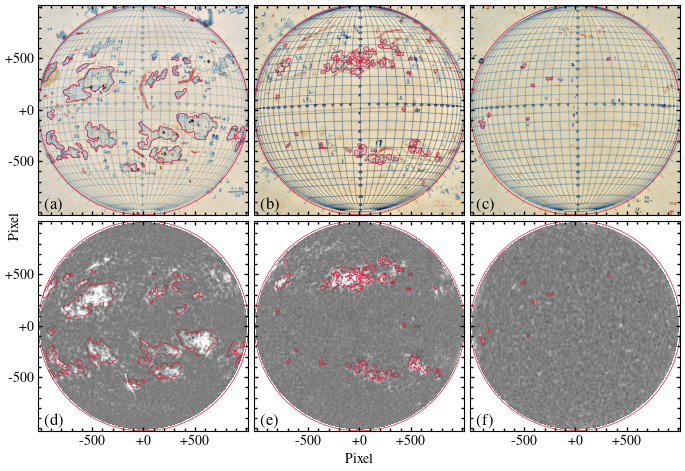

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from PIL import Image
import imutils
import matplotlib as mpl
mpl.style.use('bkj_style.mplstyle')

import astropy.units as u
# First create the AIA 1700 colormap (you may need to adjust this)
from sunpy.visualization.colormaps import color_tables as ct
sdoaia1700 = ct.aia_color_table(1700*u.angstrom)

# Image parameters
img_size = 2048  # Assuming all images are 2048x2048
center_pixel = img_size // 2  # Center at 1024 for 2048x2048 image

# Create figure
fig = plt.figure(figsize=(6, 6))

# Define axes with proper extent to prevent shifting
def create_axis(fig, rect):
    ax = fig.add_axes(rect)
    ax.set_xlim(0, img_size-1)
    ax.set_ylim(0, img_size-1)
    return ax

ax1 = create_axis(fig, [0.01, 0.37, 0.35, 0.35])
ax2 = create_axis(fig, [0.37, 0.37, 0.35, 0.35])
ax3 = create_axis(fig, [0.73, 0.37, 0.35, 0.35])
ax4 = create_axis(fig, [0.01, 0.01, 0.35, 0.35])
ax5 = create_axis(fig, [0.37, 0.01, 0.35, 0.35])
ax6 = create_axis(fig, [0.73, 0.01, 0.35, 0.35])

def configure_axis(ax, title, show_y_labels=True, show_x_labels=True):
    # Set relative pixel ticks
    rel_ticks = [-500, 0, 500]
    abs_ticks = [center_pixel + t for t in rel_ticks]
    
    ax.set_xticks(abs_ticks)
    ax.set_yticks(abs_ticks)
    ax.set_xticklabels([f"{t:+d}" for t in rel_ticks] if show_x_labels else [])
    ax.set_yticklabels([f"{t:+d}" for t in rel_ticks] if show_y_labels else [])
    ax.tick_params(axis='both', labelsize=10)
    
    # if show_x_labels:
    #     ax.set_xlabel('Pixel',fontsize=10)
    # if show_y_labels:
    #     ax.set_ylabel('Pixel',fontsize=10)
    
    ax.annotate(title, (50, 50), fontsize=12)  # Position annotation in image coordinates
    ax.grid()

# Configure axes (same as before)
configure_axis(ax1, '(a)', show_x_labels=False)
configure_axis(ax2, '(b)', show_y_labels=False, show_x_labels=False)
configure_axis(ax3, '(c)', show_y_labels=False, show_x_labels=False)
configure_axis(ax4, '(d)')
configure_axis(ax5, '(e)', show_y_labels=False)
configure_axis(ax6, '(f)', show_y_labels=False)

# Add circles
for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    circle = Circle((center_pixel, center_pixel), 1024, 
                   color='crimson', fill=False, linewidth=0.5,rasterized=True)
    ax.add_patch(circle)
    # ax.text(center_pixel, center_pixel+1100, "R=1024 px", 
    #         ha='center', color='darkcyan', fontsize=8)

# Display images with explicit extent to prevent shifting
def show_image(ax, img, contour_data=None):
    ax.imshow(img, origin='lower', extent=[0, img_size-1, 0, img_size-1], rasterized=True)
    if contour_data is not None:
        ax.contour(contour_data, alpha=0.4, colors='crimson', 
                  linestyles='-', origin='lower', linewidths=0.2,rasterized=True)

# Display each image with proper alignment
show_image(ax1, reconstruct_maxmima, filtered_img[2])
show_image(ax2, reconstruct_middle, filtered_img[1])
show_image(ax3, reconstruct_minimum, filtered_img[0])
#show_image(ax4, sav_data_max['resized_data'])
#show_image(ax5, sav_data_middle['resized_data'])
#show_image(ax6, sav_data_min['resized_data'])

# Modify the display commands for panels d, e, f:
ax4.imshow(sav_data_max['resized_data'], cmap='gray', origin='lower', 
           vmin=-0.5, vmax=0.5, rasterized=True)
ax4.contour(filtered_img[2],alpha=0.4, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)

ax5.imshow(sav_data_middle['resized_data'], cmap='gray', origin='lower',
           vmin=-0.5, vmax=0.5, rasterized=True)
ax5.contour(filtered_img[1],alpha=0.4, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)
ax5.set_xlabel('Pixel',fontsize=10)

ax6.imshow(sav_data_min['resized_data'], cmap='gray', origin='lower',
           vmin=-0.5, vmax=0.5, rasterized=True)
ax6.contour(filtered_img[0],alpha=0.4, colors='crimson', linestyles='-',origin='lower',linewidths=0.2,  rasterized=True)

fig.text(-0.04, 0.35, 'Pixel', va='center', rotation='vertical', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('activity_comp_img.pdf', bbox_inches='tight', pad_inches=0, dpi=200)
plt.show()